In [0]:
# Import SparkSession - entry point for PySpark
from pyspark.sql import SparkSession

# Import functions for DataFrame operations and SQL queries
from pyspark.sql.functions import (
    col, lit, when, expr, sum, avg, count, desc,
    to_date, year, month, dayofmonth, datediff,
    to_timestamp, lag, lead, unix_timestamp, date_format,
    window, broadcast
)

# Import Window for window functions used in time series and advanced analytics
from pyspark.sql.window import Window

# Import data types to define schema explicitly if needed
from pyspark.sql.types import IntegerType, DoubleType, StringType, DateType

# MLlib imports for feature engineering, regression, classification, clustering, evaluation, and hyperparameter tuning
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.regression import LinearRegression
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import RegressionEvaluator, BinaryClassificationEvaluator, ClusteringEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# Import storage level to control caching/persisting
from pyspark.storagelevel import StorageLevel

# For data visualization outside Spark (convert small samples to pandas)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# For testing PySpark code with unittest framework
import unittest

# Initialize SparkSession (example)
spark = SparkSession.builder.appName("SalesAnalysis").getOrCreate()


In [0]:
print("welcome")

welcome


In [0]:
# Load the data from the saved table
df = spark.table("superstore_sales_dataset")

# Show the first 10 rows of the DataFrame
df.show(2)


+------+--------------+----------+----------+------------+-----------+-------------+--------+-------------+---------+--------+-----------+------+---------------+---------+------------+--------------------+------+
|Row ID|      Order ID|Order Date| Ship Date|   Ship Mode|Customer ID|Customer Name| Segment|      Country|     City|   State|Postal Code|Region|     Product ID| Category|Sub-Category|        Product Name| Sales|
+------+--------------+----------+----------+------------+-----------+-------------+--------+-------------+---------+--------+-----------+------+---------------+---------+------------+--------------------+------+
|     1|CA-2017-152156|2017-11-08|2017-11-11|Second Class|   CG-12520|  Claire Gute|Consumer|United States|Henderson|Kentucky|      42420| South|FUR-BO-10001798|Furniture|   Bookcases|Bush Somerset Col...|261.96|
|     2|CA-2017-152156|2017-11-08|2017-11-11|Second Class|   CG-12520|  Claire Gute|Consumer|United States|Henderson|Kentucky|      42420| South|FUR

In [0]:
# Show the first 2 rows of the DataFrame
df.show(2)

+------+--------------+----------+----------+------------+-----------+-------------+--------+-------------+---------+--------+-----------+------+---------------+---------+------------+--------------------+------+
|Row ID|      Order ID|Order Date| Ship Date|   Ship Mode|Customer ID|Customer Name| Segment|      Country|     City|   State|Postal Code|Region|     Product ID| Category|Sub-Category|        Product Name| Sales|
+------+--------------+----------+----------+------------+-----------+-------------+--------+-------------+---------+--------+-----------+------+---------------+---------+------------+--------------------+------+
|     1|CA-2017-152156|2017-11-08|2017-11-11|Second Class|   CG-12520|  Claire Gute|Consumer|United States|Henderson|Kentucky|      42420| South|FUR-BO-10001798|Furniture|   Bookcases|Bush Somerset Col...|261.96|
|     2|CA-2017-152156|2017-11-08|2017-11-11|Second Class|   CG-12520|  Claire Gute|Consumer|United States|Henderson|Kentucky|      42420| South|FUR

In [0]:
# Print the schema (column names and data types)
df.printSchema()

# Show summary statistics for numeric columns
df.describe().show()

root
 |-- Row ID: long (nullable = true)
 |-- Order ID: string (nullable = true)
 |-- Order Date: date (nullable = true)
 |-- Ship Date: date (nullable = true)
 |-- Ship Mode: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Customer Name: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Postal Code: long (nullable = true)
 |-- Region: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Sub-Category: string (nullable = true)
 |-- Product Name: string (nullable = true)
 |-- Sales: double (nullable = true)

+-------+------------------+--------------+--------------+-----------+------------------+-----------+-------------+--------+-------+------------------+-------+---------------+----------+------------+--------------------+------------------+
|summary|            Row ID|     

In [0]:
#Data Cleaning (drop duplicates, drop nulls, modify schema)
from pyspark.sql.functions import col

# Drop duplicate rows
df_cleaned = df.dropDuplicates()

# Drop rows with any null values
df_cleaned = df_cleaned.dropna()

# Cast specific columns to appropriate data types
df_cleaned = df_cleaned.withColumn("Sales", col("Sales").cast("double")) \
                       .withColumn("Postal Code", col("Postal Code").cast("string")) \
                       .withColumn("Order Date", col("Order Date").cast("date")) \
                       .withColumn("Ship Date", col("Ship Date").cast("date"))

# Verify schema after type casting
df_cleaned.printSchema()

# Show a few cleaned rows
df_cleaned.show(5)


root
 |-- Row ID: long (nullable = true)
 |-- Order ID: string (nullable = true)
 |-- Order Date: date (nullable = true)
 |-- Ship Date: date (nullable = true)
 |-- Ship Mode: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Customer Name: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Postal Code: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Sub-Category: string (nullable = true)
 |-- Product Name: string (nullable = true)
 |-- Sales: double (nullable = true)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+-------------+--------------+-----------+------+---------------+---------------+------------+--------------------+------+
|Row ID|      Order ID|Order Date| Sh

In [0]:
from pyspark.sql.functions import sum, desc
# Top 10 customers by total sales
top_customers = df_cleaned.groupBy("Customer Name") \
                          .agg(sum("Sales").alias("Total_Sales")) \
                          .orderBy(desc("Total_Sales")) \
                          .limit(10)

top_customers.show()

+------------------+------------------+
|     Customer Name|       Total_Sales|
+------------------+------------------+
|       Sean Miller|          25043.05|
|      Tamara Chand|         19052.218|
|      Raymond Buch|         15117.339|
|      Tom Ashbrook|          14595.62|
|     Adrian Barton|14473.570999999996|
|      Ken Lonsdale|14175.229000000001|
|      Sanjit Chand|         14142.334|
|      Hunter Lopez|         12873.298|
|      Sanjit Engle|         12209.438|
|Christopher Conant|12129.072000000002|
+------------------+------------------+



In [0]:
# Total sales by Region
df_cleaned.groupBy("Region") \
          .agg(sum("Sales").alias("Total_Sales")) \
          .orderBy(desc("Total_Sales")) \
          .show()

# Total sales by State
df_cleaned.groupBy("State") \
          .agg(sum("Sales").alias("Total_Sales")) \
          .orderBy(desc("Total_Sales")) \
          .show()

# Total sales by City
df_cleaned.groupBy("City") \
          .agg(sum("Sales").alias("Total_Sales")) \
          .orderBy(desc("Total_Sales")) \
          .show()

# Total sales by Country (in case there's more than one)
df_cleaned.groupBy("Country") \
          .agg(sum("Sales").alias("Total_Sales")) \
          .orderBy(desc("Total_Sales")) \
          .show()


+-------+------------------+
| Region|       Total_Sales|
+-------+------------------+
|   West| 710219.6845000015|
|   East| 660589.3559999982|
|Central|492646.91320000123|
|  South| 389151.4590000003|
+-------+------------------+

+--------------+------------------+
|         State|       Total_Sales|
+--------------+------------------+
|    California|446306.46350000205|
|      New York| 306361.1470000003|
|         Texas| 168572.5321999999|
|    Washington|135206.84999999998|
|  Pennsylvania| 116276.6499999999|
|       Florida| 88436.53199999995|
|      Illinois| 79236.51699999995|
|      Michigan| 76136.07400000007|
|          Ohio| 75130.35000000006|
|      Virginia| 70636.71999999999|
|North Carolina| 55165.96399999999|
|       Indiana|           48718.4|
|       Georgia| 48219.11000000001|
|      Kentucky| 36458.38999999998|
|       Arizona| 35272.65700000001|
|    New Jersey|         34610.972|
|      Colorado|31841.597999999987|
|     Wisconsin|31173.430000000022|
|     Tenne

In [0]:
from pyspark.sql.functions import year, month, quarter

# Add time-based columns
df_time = df_cleaned.withColumn("Year", year("Order Date")) \
                    .withColumn("Month", month("Order Date")) \
                    .withColumn("Quarter", quarter("Order Date"))

# Yearly sales
df_time.groupBy("Year") \
       .agg(sum("Sales").alias("Yearly_Sales")) \
       .orderBy("Year") \
       .show()

# Monthly sales
df_time.groupBy("Year", "Month") \
       .agg(sum("Sales").alias("Monthly_Sales")) \
       .orderBy("Year", "Month") \
       .show()

# Quarterly sales
df_time.groupBy("Year", "Quarter") \
       .agg(sum("Sales").alias("Quarterly_Sales")) \
       .orderBy("Year", "Quarter") \
       .show()


+----+------------------+
|Year|      Yearly_Sales|
+----+------------------+
|2015| 479856.2081000008|
|2016|454315.90540000045|
|2017| 597225.4900000002|
|2018| 721209.8091999989|
+----+------------------+

+----+-----+------------------+
|Year|Month|     Monthly_Sales|
+----+-----+------------------+
|2015|    1|14205.707000000004|
|2015|    2| 4519.891999999999|
|2015|    3|         55205.797|
|2015|    4|27906.854999999985|
|2015|    5|23644.302999999996|
|2015|    6| 34322.93560000001|
|2015|    7| 33781.54300000002|
|2015|    8|27117.536499999977|
|2015|    9|        81623.5268|
|2015|   10|31453.392999999985|
|2015|   11| 77907.66069999998|
|2015|   12| 68167.05849999994|
|2016|    1|18066.957600000005|
|2016|    2|11951.410999999996|
|2016|    3|        32339.3184|
|2016|    4| 34154.46849999998|
|2016|    5|29959.530500000015|
|2016|    6| 23599.37399999999|
|2016|    7| 28608.25899999999|
|2016|    8|        36818.3422|
+----+-----+------------------+
only showing top 20 row

In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rank

# Define window by Region, ordered by sales descending
window_spec = Window.partitionBy("Region").orderBy(desc("Total_Sales"))

# Calculate total sales per customer per region
customer_sales_region = df_cleaned.groupBy("Region", "Customer Name") \
                                  .agg(sum("Sales").alias("Total_Sales"))

# Apply ranking
ranked_customers = customer_sales_region.withColumn("Rank", rank().over(window_spec))

# Filter to get top 3 customers per region
top_customers_per_region = ranked_customers.filter("Rank <= 3")

top_customers_per_region.show()


+-------+--------------+------------------+----+
| Region| Customer Name|       Total_Sales|Rank|
+-------+--------------+------------------+----+
|Central|  Tamara Chand|         18437.138|   1|
|Central| Adrian Barton|12181.593999999997|   2|
|Central|  Becky Martin|10539.895999999999|   3|
|   East|  Tom Ashbrook|         13723.498|   1|
|   East|  Hunter Lopez|          10522.55|   2|
|   East|  Bill Shonely|         10022.293|   3|
|  South|   Sean Miller|         23669.196|   1|
|  South|  Sanjit Engle|           8805.04|   2|
|  South|Grant Thornton| 8167.419999999999|   3|
|   West|  Raymond Buch|         14345.276|   1|
|   West|  Ken Lonsdale|          8472.394|   2|
|   West|  Edward Hooks| 7408.089999999998|   3|
+-------+--------------+------------------+----+



In [0]:
from pyspark.sql.functions import min

# First order date per customer
first_order = df_cleaned.groupBy("Customer Name") \
                        .agg(min("Order Date").alias("First_Order_Date")) \
                        .orderBy("First_Order_Date")

first_order.show()


+-----------------+----------------+
|    Customer Name|First_Order_Date|
+-----------------+----------------+
|    Darren Powers|      2015-01-03|
|    Phillina Ober|      2015-01-04|
|       Mick Brown|      2015-01-05|
| Lycoris Saunders|      2015-01-06|
|    Maria Etezadi|      2015-01-06|
|    Jack O'Briant|      2015-01-06|
| Vivek Sundaresam|      2015-01-07|
|    Melanie Seite|      2015-01-09|
|   Anthony Jacobs|      2015-01-10|
|      Seth Vernon|      2015-01-11|
|     Brian Dahlen|      2015-01-13|
|Natalie DeCherney|      2015-01-13|
|    Michael Moore|      2015-01-13|
|  Chris Selesnick|      2015-01-13|
|    Brendan Sweed|      2015-01-14|
|    Erica Hackney|      2015-01-15|
|Delfina Latchford|      2015-01-16|
|     David Wiener|      2015-01-18|
|    Toby Swindell|      2015-01-19|
|     Xylona Preis|      2015-01-20|
+-----------------+----------------+
only showing top 20 rows


In [0]:
from pyspark.sql.functions import date_format
import pandas as pd

# Group by Year-Month and aggregate sales
monthly_sales = df_cleaned.withColumn("YearMonth", date_format("Order Date", "yyyy-MM")) \
                          .groupBy("YearMonth") \
                          .agg(sum("Sales").alias("Total_Sales")) \
                          .orderBy("YearMonth")

# Convert to Pandas for time series modeling
monthly_sales_pd = monthly_sales.toPandas()

# Convert YearMonth to datetime type and set as index
monthly_sales_pd['YearMonth'] = pd.to_datetime(monthly_sales_pd['YearMonth'])
monthly_sales_pd.set_index('YearMonth', inplace=True)

monthly_sales_pd.head()


,Total_Sales
YearMonth,
2015-01-01,14205.707
2015-02-01,4519.892
2015-03-01,55205.797
2015-04-01,27906.855
2015-05-01,23644.303


In [0]:
%pip install pmdarima


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=866.859, Time=1.93 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=872.764, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=867.248, Time=0.03 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=865.068, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=928.258, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=872.667, Time=0.02 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=866.418, Time=0.07 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=863.687, Time=0.20 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=865.561, Time=0.24 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=864.069, Time=0.09 sec
 ARIMA(1,0,1)(0,0,2)[12] intercept   : AIC=865.461, Time=0.10 sec
 ARIMA(0,0,2)(0,0,2)[12] intercept   : AIC=866.095, Time=0.14 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=863.871, Time=0.07 sec
 ARIMA(1,0,2)(0,0,2)[12] intercept   : AIC=867.807, Time=0.10 sec
 ARIMA(0,0,1)(0,0,2)[12]         

/home/spark-9fddcc12-aaed-455a-a845-86/.ipykernel/16714/command-7345175405498515-2737937340:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Forecast'] = forecast


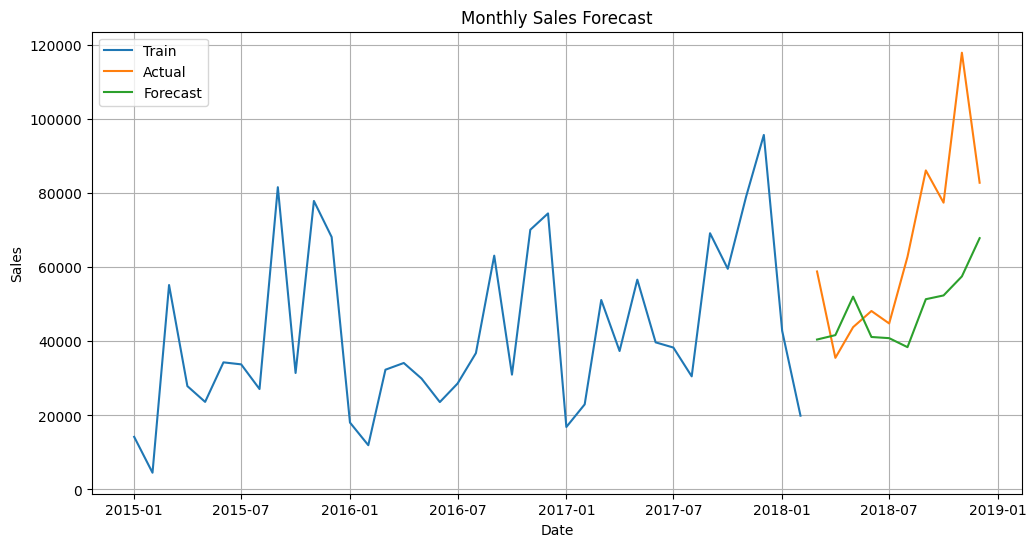

In [0]:
# Install if not already installed
# %pip install pmdarima

from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Train-test split (e.g., 80% train, 20% test)
train_size = int(len(monthly_sales_pd) * 0.8)
train, test = monthly_sales_pd.iloc[:train_size], monthly_sales_pd.iloc[train_size:]

# Fit AutoARIMA
model = auto_arima(train, seasonal=True, m=12, trace=True,
                   suppress_warnings=True, stepwise=True)

# Forecast
n_periods = len(test)
forecast = model.predict(n_periods=n_periods)

# Compare actual vs predicted
test['Forecast'] = forecast

# Plot
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Total_Sales'], label='Train')
plt.plot(test.index, test['Total_Sales'], label='Actual')
plt.plot(test.index, test['Forecast'], label='Forecast')
plt.legend()
plt.title("Monthly Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()


In [0]:
# Calculate evaluation metrics
mse = mean_squared_error(test['Total_Sales'], test['Forecast'])
mae = mean_absolute_error(test['Total_Sales'], test['Forecast'])
r2 = r2_score(test['Total_Sales'], test['Forecast'])

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R² Score:", r2)


Mean Squared Error (MSE): 681325783.4362911
Mean Absolute Error (MAE): 20333.54609653644
R² Score: -0.1821427161067215


In [0]:
# Filter rows where State is in a specific list
df_cleaned.filter(df_cleaned["State"].isin("California", "New York", "Texas")) \
          .select("Customer Name", "State", "Sales") \
          .show(5)


+-----------------+----------+-------+
|    Customer Name|     State|  Sales|
+-----------------+----------+-------+
|  Matt Hagelstein|California| 1145.6|
|    Brendan Murry|  New York|  12.96|
|    Cindy Stewart|California|  12.84|
|         John Lee|California|287.968|
|Steven Cartwright|     Texas|   2.08|
+-----------------+----------+-------+
only showing top 5 rows


In [0]:
from pyspark.sql.functions import when

# Add a column categorizing sales into 'High', 'Medium', 'Low'
df_conditional = df_cleaned.select(
    "Customer Name", "Sales",
    when(df_cleaned["Sales"] > 1000, "High")
    .when((df_cleaned["Sales"] >= 500) & (df_cleaned["Sales"] <= 1000), "Medium")
    .otherwise("Low")
    .alias("Sales_Category")
)

df_conditional.show(5)


+---------------+------+--------------+
|  Customer Name| Sales|Sales_Category|
+---------------+------+--------------+
|   Larry Hughes|271.96|           Low|
| Arianne Irving|63.686|           Low|
|Matt Hagelstein|1145.6|          High|
|  Brendan Murry| 12.96|           Low|
|  Cindy Stewart| 12.84|           Low|
+---------------+------+--------------+
only showing top 5 rows


In [0]:
# Product names that contain the word 'Chair'
df_cleaned.filter(df_cleaned["Product Name"].like("%Chair%")) \
          .select("Product Name", "Sales") \
          .show(5)


+--------------------+-------+
|        Product Name|  Sales|
+--------------------+-------+
|Leather Task Chai...| 63.686|
|Global Deluxe Off...| 287.94|
|Tenex 46" x 60" C...| 211.96|
|DMI Arturo Collec...|271.764|
|Tenex Contemporar...|258.072|
+--------------------+-------+
only showing top 5 rows


In [0]:
# Cities starting with 'San'
df_cleaned.filter(df_cleaned["City"].startswith("San")) \
          .select("City", "Sales") \
          .show(5)

# Product names ending with 'Desk'
df_cleaned.filter(df_cleaned["Product Name"].endswith("Desk")) \
          .select("Product Name", "Sales") \
          .show(5)


+-------------+------+
|         City| Sales|
+-------------+------+
|San Francisco|1145.6|
|San Francisco| 12.84|
|    San Diego| 62.24|
|    San Diego| 143.7|
|  San Antonio|177.98|
+-------------+------+
only showing top 5 rows
+------------+-----+
|Product Name|Sales|
+------------+-----+
+------------+-----+



In [0]:
from pyspark.sql.functions import col

# Extract year from Order Date (assuming it's a DateType)
df_cleaned.select(
    "Order Date",
    col("Order Date").substr(1, 4).alias("Order_Year")
).show(5)


+----------+----------+
|Order Date|Order_Year|
+----------+----------+
|2018-08-01|      2018|
|2018-12-11|      2018|
|2018-07-28|      2018|
|2016-09-15|      2016|
|2016-05-12|      2016|
+----------+----------+
only showing top 5 rows


In [0]:
# Example: total sales per region
df_region_sales = df_cleaned.groupBy("Region") \
                            .agg(sum("Sales").alias("Total_Sales")) \
                            .toPandas()


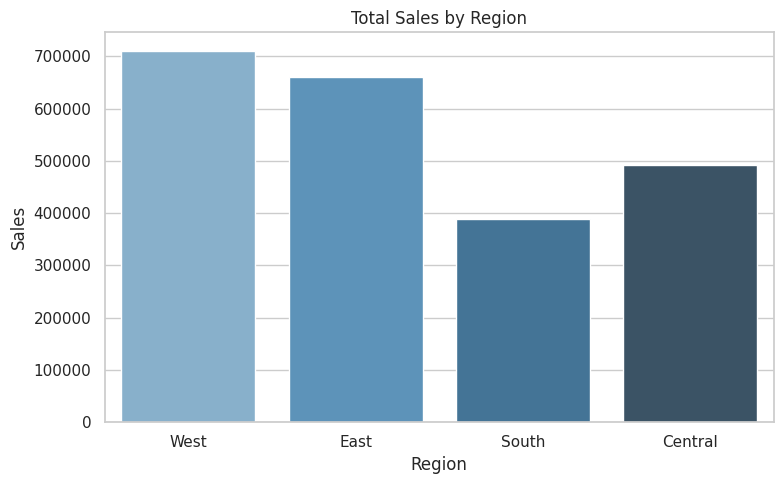

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Bar plot
plt.figure(figsize=(8, 5))
sns.barplot(data=df_region_sales, x="Region", y="Total_Sales", palette="Blues_d")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


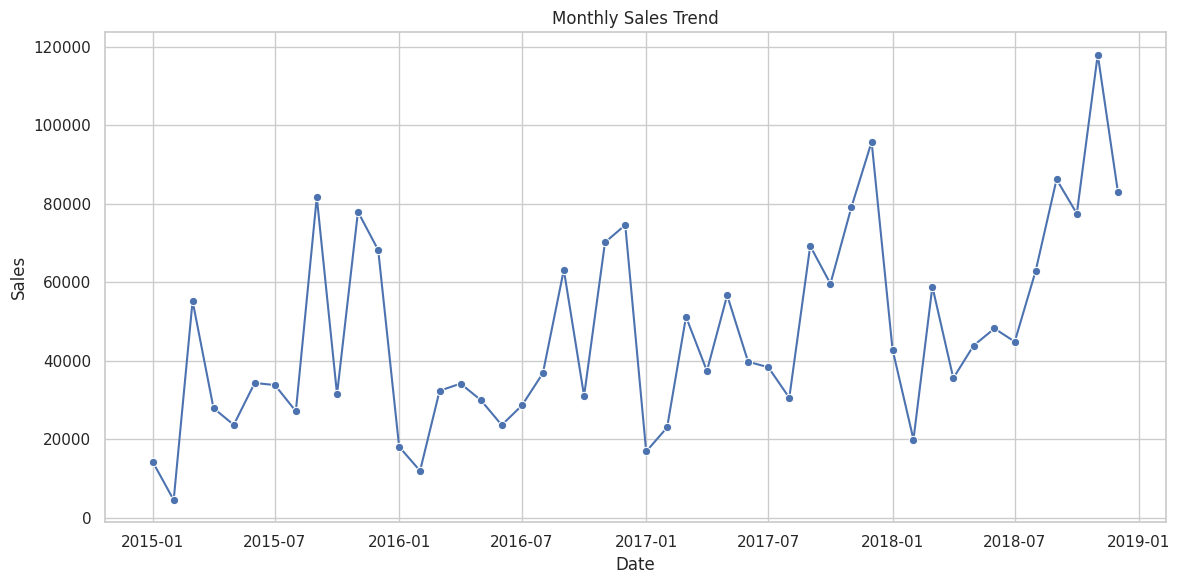

In [0]:
# Prepare monthly sales data
from pyspark.sql.functions import date_format

df_monthly = df_cleaned.withColumn("YearMonth", date_format("Order Date", "yyyy-MM")) \
                       .groupBy("YearMonth") \
                       .agg(sum("Sales").alias("Total_Sales")) \
                       .orderBy("YearMonth") \
                       .toPandas()

# Convert to datetime
df_monthly["YearMonth"] = pd.to_datetime(df_monthly["YearMonth"])

# Line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_monthly, x="YearMonth", y="Total_Sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.show()


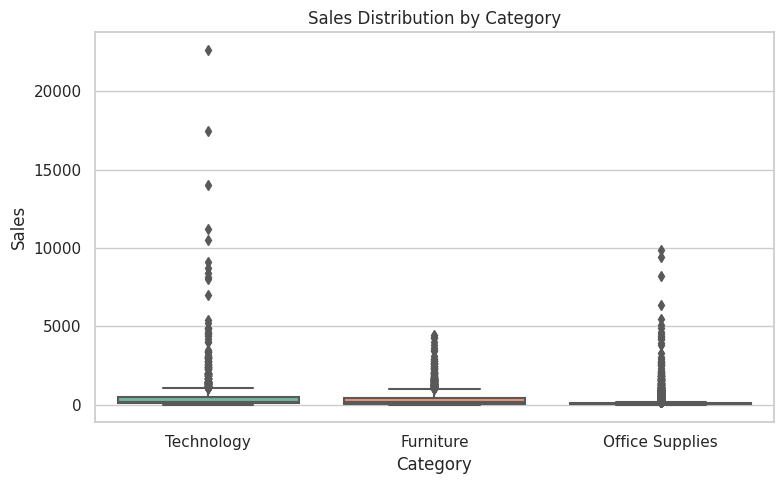

In [0]:
# Get category-wise data
df_cat_sales = df_cleaned.select("Category", "Sales").toPandas()

# Box plot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cat_sales, x="Category", y="Sales", palette="Set2")
plt.title("Sales Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


In [0]:
print("thank you")

thank you
